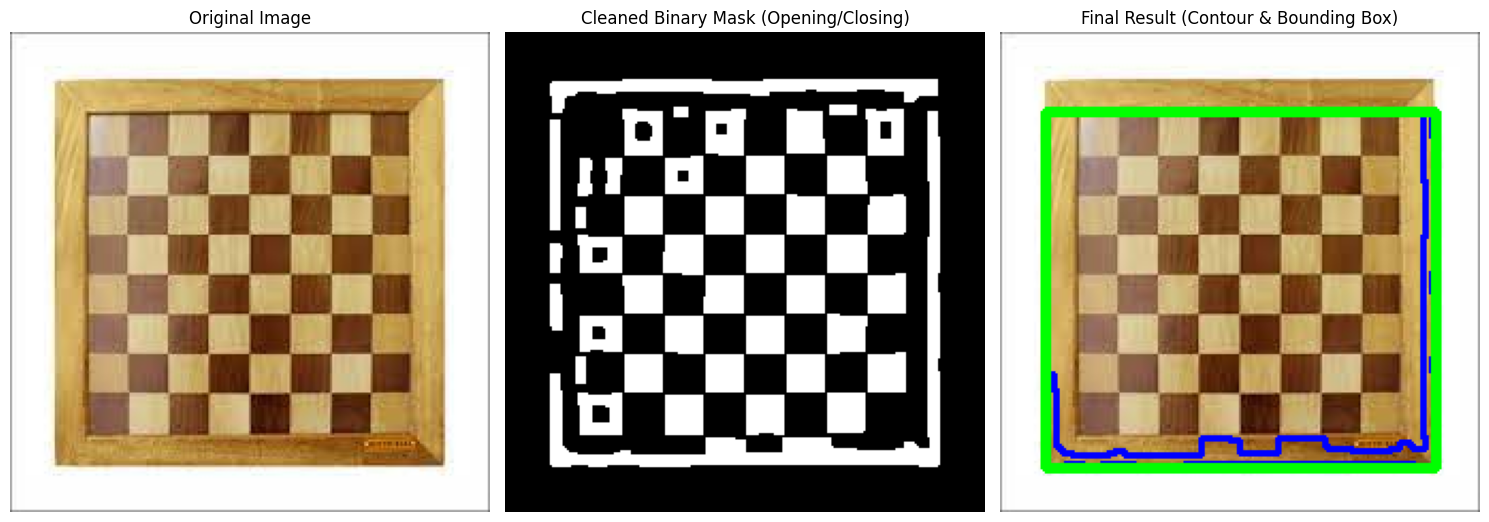

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Set the filename ---
IMAGE_FILE = 'xadrez.jpg'

## 1. Load and Preprocess the Image
# Load the image
img = cv2.imread(IMAGE_FILE)

if img is None:
    print(f"Error: Could not load image file '{IMAGE_FILE}'")
    exit()

# Create a copy to draw on
output_img = img.copy()

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply a strong Gaussian blur to suppress noise and smooth edges
# This is crucial for both edge and thresholding techniques
blurred = cv2.GaussianBlur(gray, (11, 11), 0)

## 2. Adaptive Thresholding to Create a Binary Mask
# Adaptive Thresholding calculates the threshold for small regions
# which is better than a single global threshold for an image with
# varying illumination (like the cat wrapped in a blanket).
binary_mask = cv2.adaptiveThreshold(
    blurred,
    255,  # Max value for output
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C, # Adaptive method
    cv2.THRESH_BINARY_INV,        # Type of thresholding (we want the cat as white)
    21,                           # Block Size: Size of the neighborhood
    5                             # C: Constant subtracted from the mean
)

## 3. Morphological Operations for Noise Reduction and Gap Filling
# Define the kernel size for the morphological operations
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))

# Closing: Fills small holes and gaps within the object
closing = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel, iterations=2)

# Opening: Removes small objects/noise outside the cat
opening = cv2.morphologyEx(closing, cv2.MORPH_OPEN, kernel, iterations=2)

## 4. Find and Filter the Main Contour
# Find contours on the cleaned mask
contours, _ = cv2.findContours(opening, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if contours:
    # Sort the contours by area in descending order
    # The largest contour should be the cat
    largest_contour = max(contours, key=cv2.contourArea)

    # Filter out very small areas that are likely residual noise
    # Adjust this value based on your image resolution (e.g., 1/100th of the image area)
    MIN_AREA_THRESHOLD = img.shape[0] * img.shape[1] / 500  
    
    if cv2.contourArea(largest_contour) > MIN_AREA_THRESHOLD:
        
        ## 5. Draw the Bounding Rectangle and Full Contour
        # 5a. Draw the full contour (Optional: shows the precise outline used)
        cv2.drawContours(output_img, [largest_contour], -1, (255, 0, 0), 2) # Blue color

        # 5b. Get and Draw the Bounding Box
        x, y, w, h = cv2.boundingRect(largest_contour)
        cv2.rectangle(output_img, (x, y), (x + w, y + h), (0, 255, 0), 3) # Green color
        
    else:
        print("No significant contour found above the area threshold.")
else:
    print("No contours were found.")

## 6. Display the Result
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# Original Image
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Image')
axes[0].axis('off')

# Binary Mask (Intermediate Step)
axes[1].imshow(opening, cmap='gray')
axes[1].set_title('Cleaned Binary Mask (Opening/Closing)')
axes[1].axis('off')

# Final Result
axes[2].imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
axes[2].set_title('Final Result (Contour & Bounding Box)')
axes[2].axis('off')

plt.tight_layout()
plt.show()
#